# Loan Approval Prediction System

This notebook contains the complete pipeline for the Loan Approval Prediction project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
import joblib

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import shap

os.makedirs('../assets', exist_ok=True)
os.makedirs('../Model', exist_ok=True)


## 1. Data Understanding

- Shape
- Info
- Summary Statistics
- Missing Values
- Duplicate Analysis

In [2]:
df = pd.read_csv('../Dataset/train.csv')
print("Shape:", df.shape)
print("\nInfo:")
df.info()
print("\nSummary Statistics:")
display(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())


Shape: (614, 13)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB

Summary Statistics:


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000



Missing Values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Duplicates: 0


## 2. Data Cleaning

- Missing Value Handling
- Duplicate Removal
- Data Validation

In [3]:
df.drop_duplicates(inplace=True)

if 'Loan_ID' in df.columns:
    df.drop('Loan_ID', axis=1, inplace=True)

df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})
df.dropna(subset=['Loan_Status'], inplace=True)


## 3. Exploratory Data Analysis

- Loan Status Distribution
- Gender Distribution
- Education Distribution
- Property Area Distribution
- Applicant Income Histogram
- Loan Amount Histogram
- Credit History vs Loan Status
- Correlation Heatmap
- Boxplots

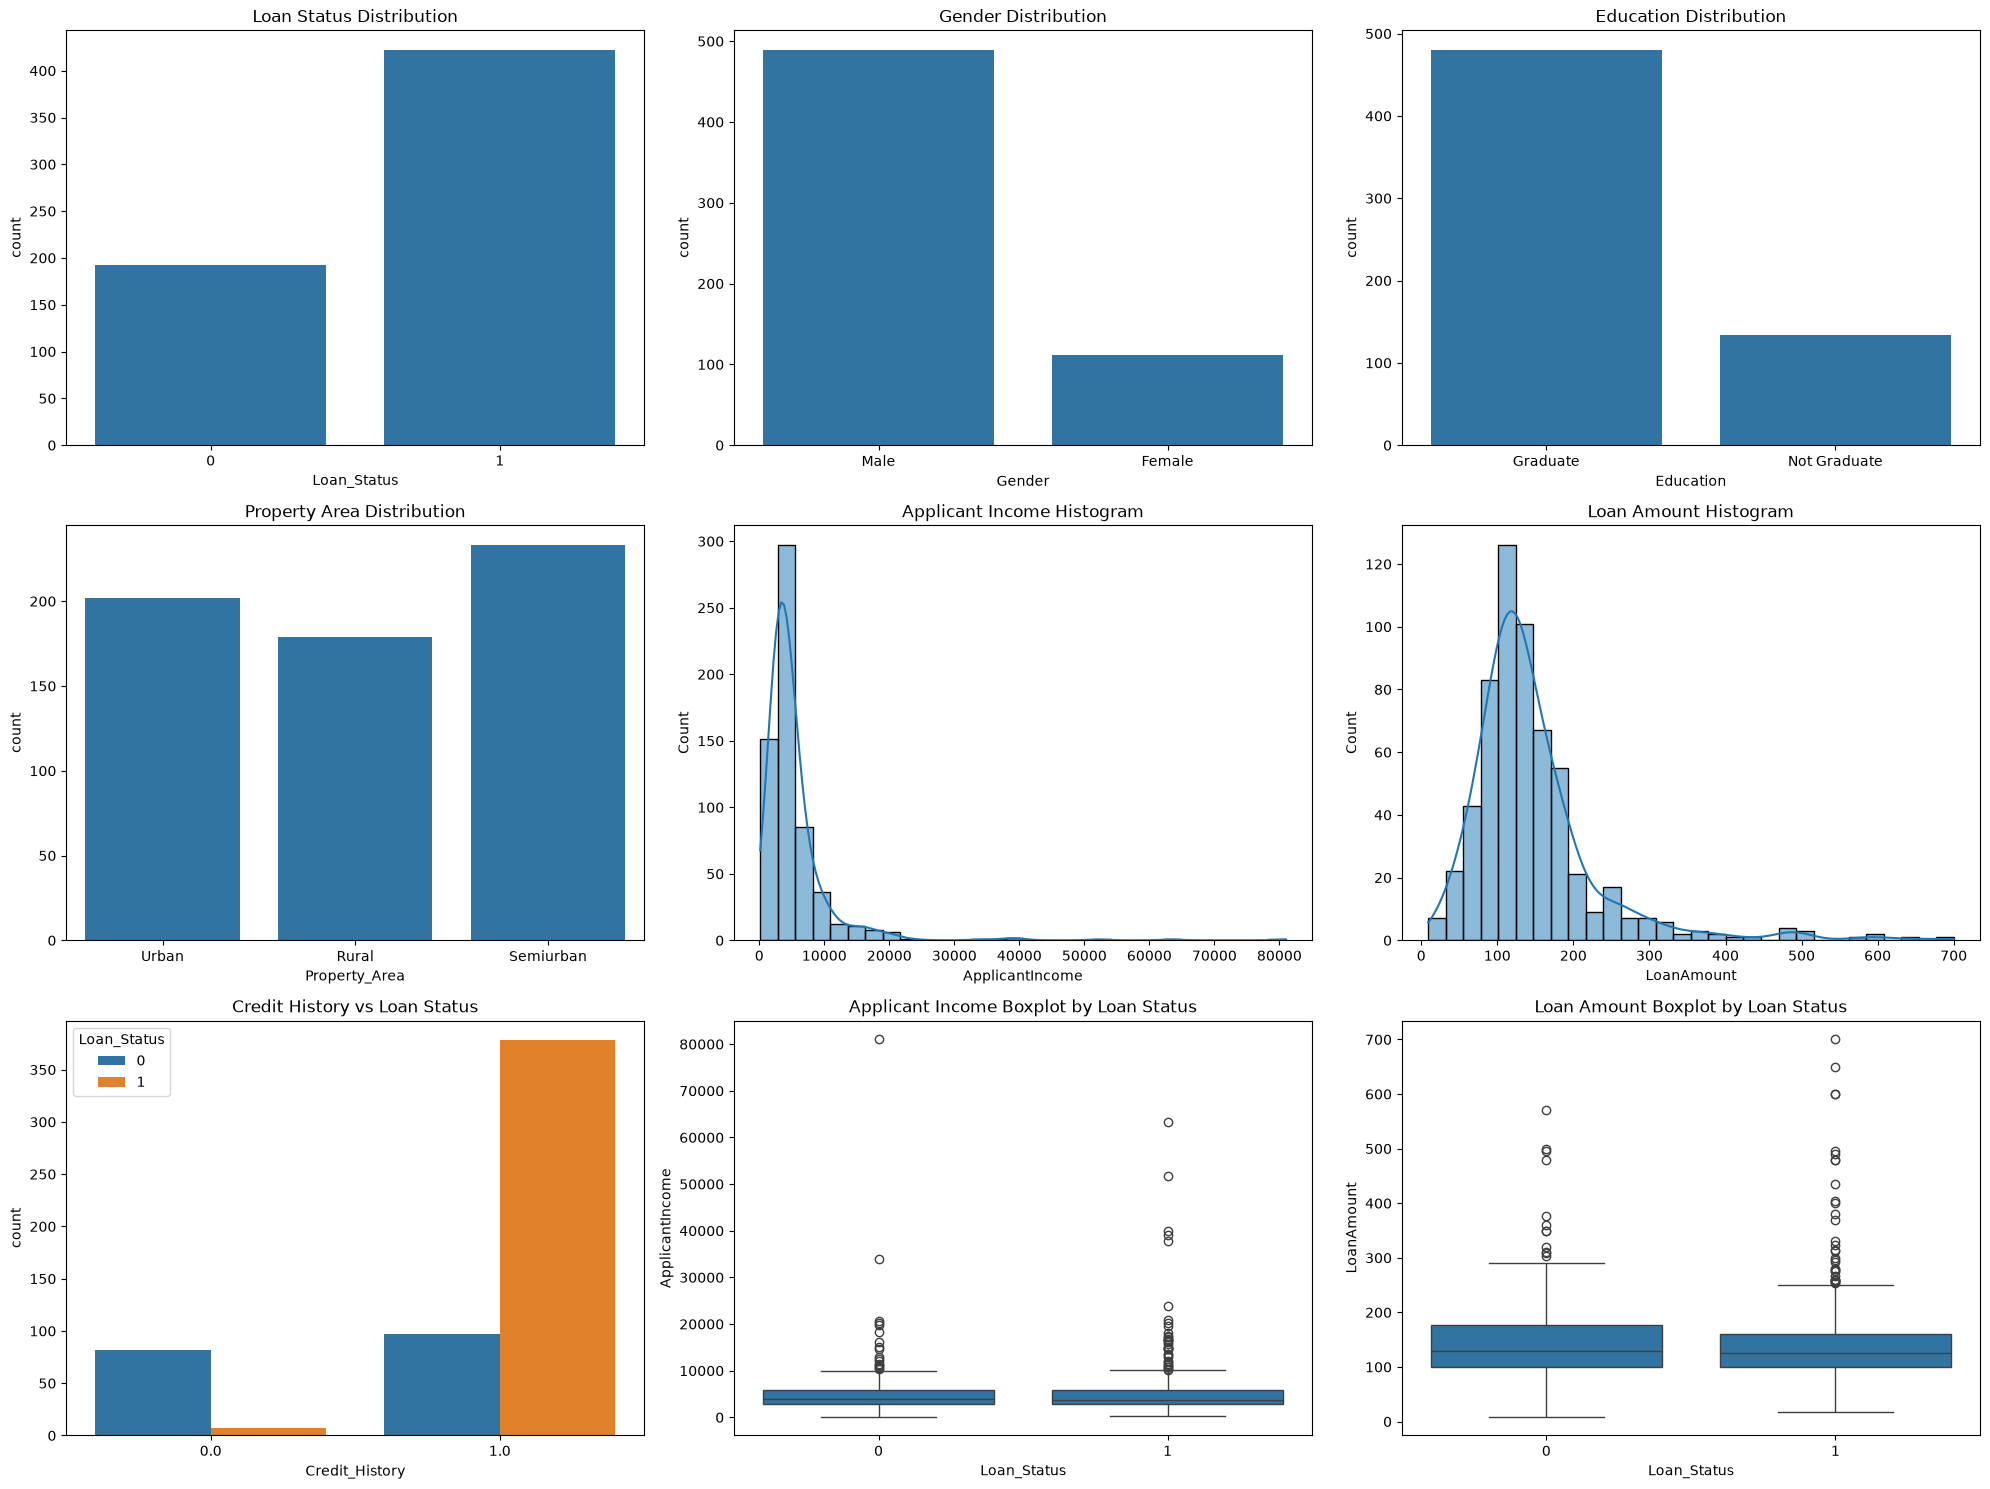

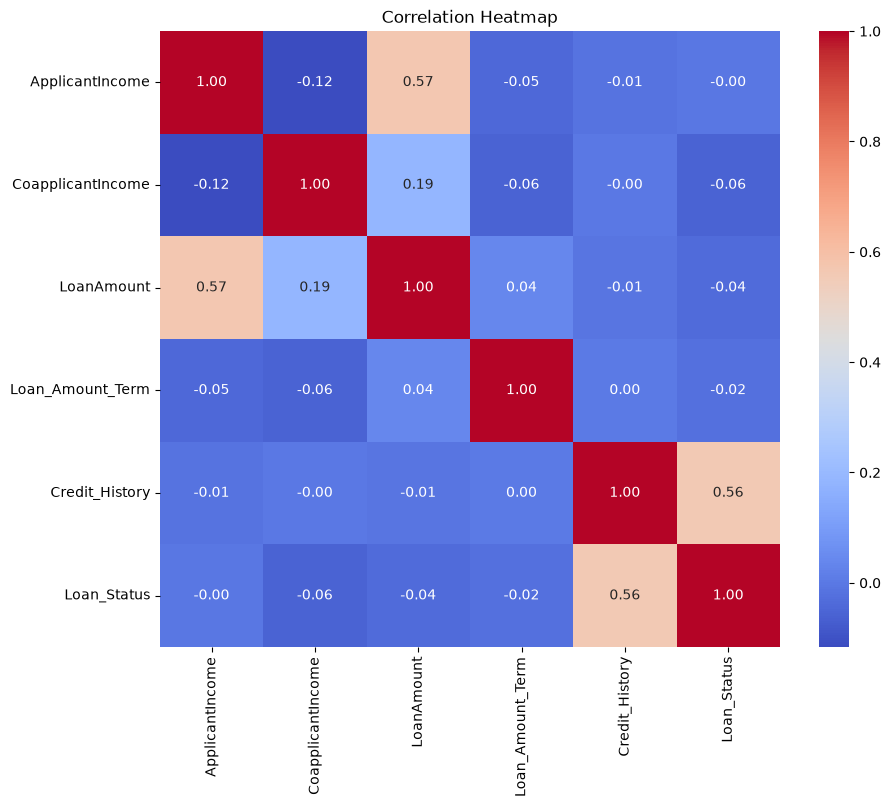

In [4]:
plt.figure(figsize=(20, 15))

plt.subplot(3, 3, 1)
sns.countplot(x='Loan_Status', data=df)
plt.title('Loan Status Distribution')

plt.subplot(3, 3, 2)
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')

plt.subplot(3, 3, 3)
sns.countplot(x='Education', data=df)
plt.title('Education Distribution')

plt.subplot(3, 3, 4)
sns.countplot(x='Property_Area', data=df)
plt.title('Property Area Distribution')

plt.subplot(3, 3, 5)
sns.histplot(df['ApplicantIncome'], bins=30, kde=True)
plt.title('Applicant Income Histogram')

plt.subplot(3, 3, 6)
sns.histplot(df['LoanAmount'], bins=30, kde=True)
plt.title('Loan Amount Histogram')

plt.subplot(3, 3, 7)
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title('Credit History vs Loan Status')

plt.subplot(3, 3, 8)
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.title('Applicant Income Boxplot by Loan Status')

plt.subplot(3, 3, 9)
sns.boxplot(x='Loan_Status', y='LoanAmount', data=df)
plt.title('Loan Amount Boxplot by Loan Status')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.savefig('../assets/heatmap.png')
plt.show()


## 4. Feature Engineering

- TotalIncome
- Income_Loan_Ratio

In [5]:
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['Income_Loan_Ratio'] = df['TotalIncome'] / (df['LoanAmount'].replace(0, np.nan))

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


## Preprocessing Pipeline Setup

In [6]:
numeric_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'TotalIncome', 'Income_Loan_Ratio']
categorical_features = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


## 5, 6, 7. Model Building, Cross Validation, Hyperparameter Tuning

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {
            'classifier__C': [0.1, 1.0, 10.0]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [50, 100],
            'classifier__max_depth': [5, 10, None],
            'classifier__min_samples_split': [2, 5]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, eval_metric='logloss'),
        'params': {
            'classifier__n_estimators': [50, 100],
            'classifier__max_depth': [3, 5],
            'classifier__learning_rate': [0.01, 0.1]
        }
    }
}

best_models = {}
for name, m in models.items():
    print(f"Training {name}...")
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', m['model'])])
    
    search = RandomizedSearchCV(pipeline, param_distributions=m['params'], n_iter=5, cv=cv, scoring='f1', random_state=42, n_jobs=-1)
    search.fit(X_train, y_train)
    
    best_models[name] = search.best_estimator_
    print(f"Best params for {name}: {search.best_params_}")


Training Logistic Regression...


Best params for Logistic Regression: {'classifier__C': 0.1}
Training Random Forest...


Best params for Random Forest: {'classifier__n_estimators': 50, 'classifier__min_samples_split': 2, 'classifier__max_depth': 5}
Training XGBoost...


Best params for XGBoost: {'classifier__n_estimators': 100, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01}


## 8. Model Evaluation

Metrics: Accuracy, Precision, Recall, F1 Score, ROC-AUC, Confusion Matrix

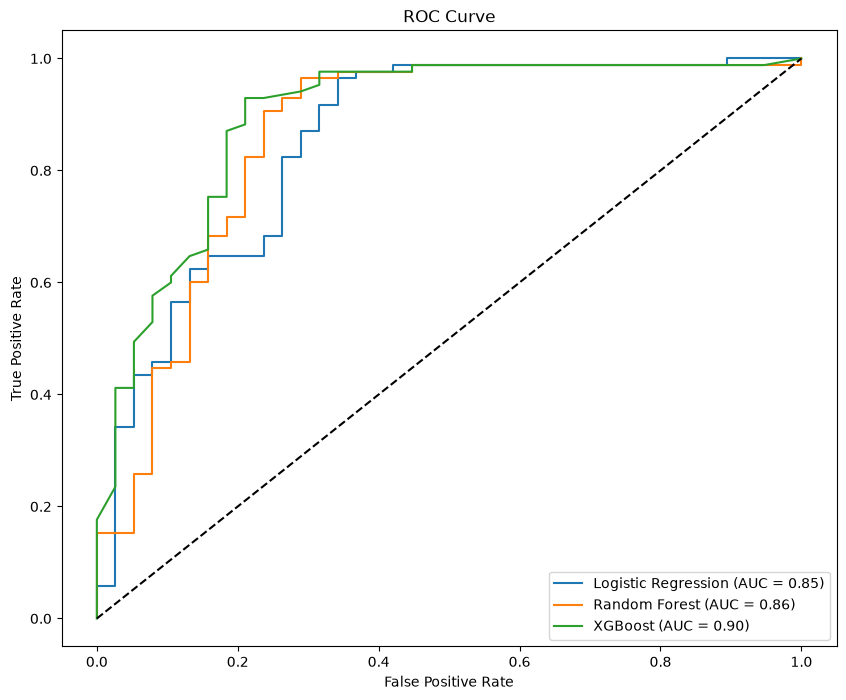

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.861789,0.840000,0.988235,0.908108,0.853251
1,Random Forest,0.845528,0.830000,0.976471,0.897297,0.860991
2,XGBoost,0.853659,0.838384,0.976471,0.902174,0.895356


In [8]:
results = []
plt.figure(figsize=(10, 8))

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC-AUC': roc_auc
    })
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig('../assets/roc_curve.png')
plt.show()

results_df = pd.DataFrame(results)
display(results_df)


## 9. Model Selection

Automatically choose the best model based on F1 Score and ROC-AUC.


Best Model selected: Logistic Regression


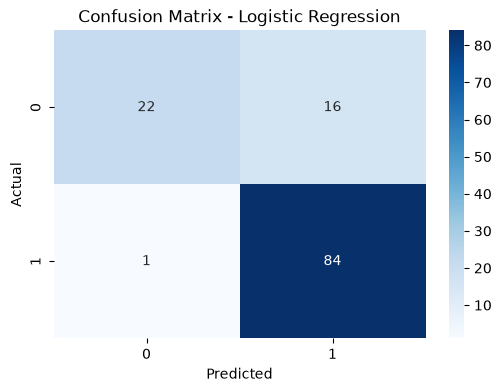

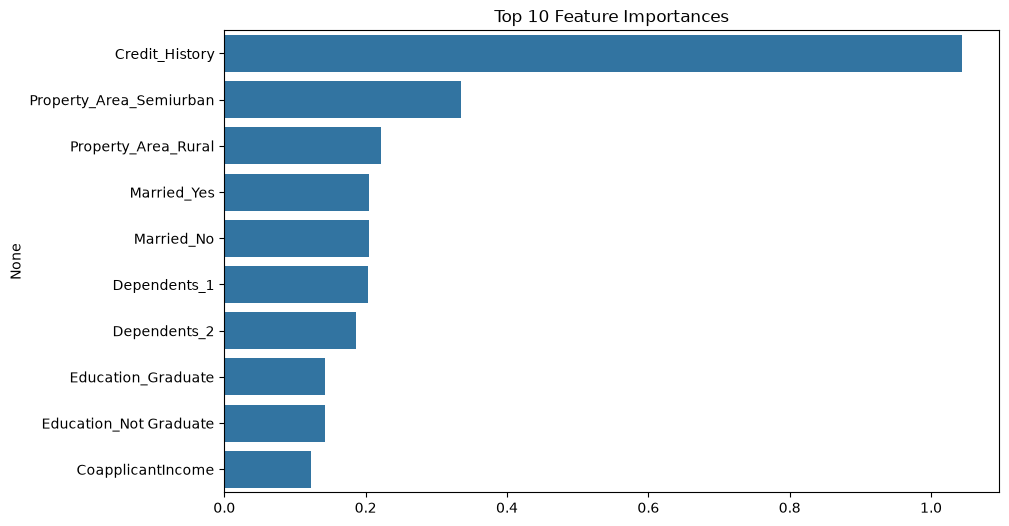

Background dataset has 491 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=491 when initializing the masker.


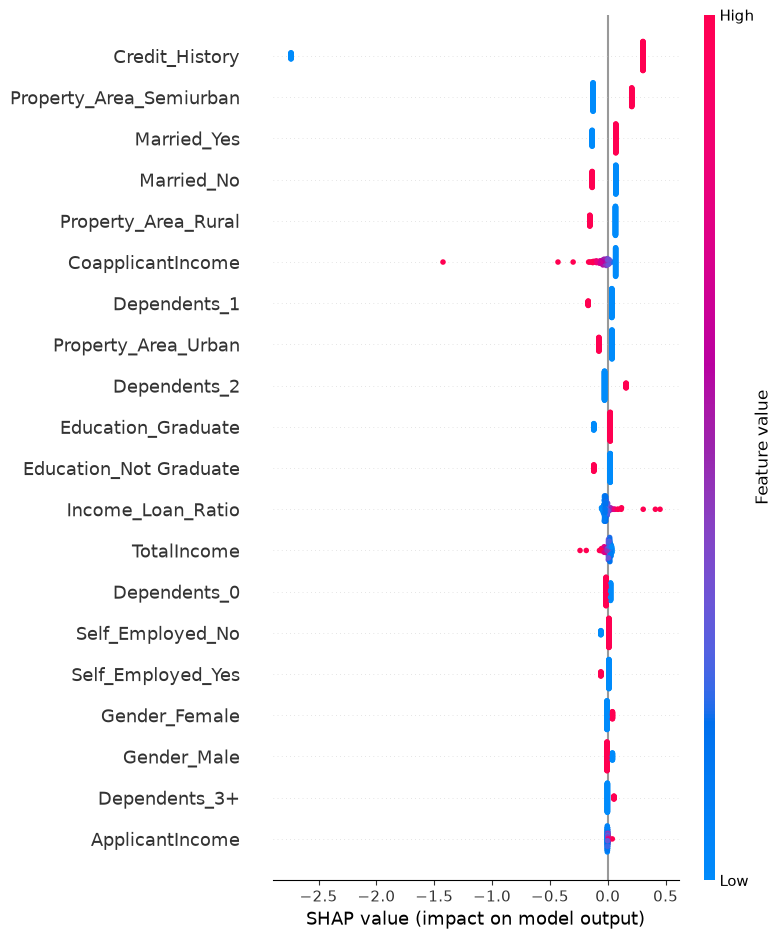

In [9]:
best_model_name = results_df.sort_values(by=['F1 Score', 'ROC-AUC'], ascending=False).iloc[0]['Model']
print(f"\nBest Model selected: {best_model_name}")

final_model = best_models[best_model_name]

y_pred_best = final_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../assets/confusion_matrix.png')
plt.show()

classifier = final_model.named_steps['classifier']

num_cols = numeric_features
cat_cols = final_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
feature_names = list(num_cols) + list(cat_cols)

if hasattr(classifier, 'feature_importances_'):
    importances = classifier.feature_importances_
else:
    importances = np.abs(classifier.coef_[0])
    
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Top 10 Feature Importances')
plt.savefig('../assets/feature_importance.png')
plt.show()

try:
    X_train_transformed = final_model.named_steps['preprocessor'].transform(X_train)
    X_test_transformed = final_model.named_steps['preprocessor'].transform(X_test)
    
    import scipy
    if scipy.sparse.issparse(X_test_transformed):
        X_test_dense = X_test_transformed.toarray()
        X_train_dense = X_train_transformed.toarray()
    else:
        X_test_dense = X_test_transformed
        X_train_dense = X_train_transformed
        
    if best_model_name in ['Random Forest', 'XGBoost']:
        explainer = shap.TreeExplainer(classifier)
        shap_values = explainer.shap_values(X_test_dense)
    else:
        explainer = shap.LinearExplainer(classifier, X_train_dense)
        shap_values = explainer.shap_values(X_test_dense)
        
    plt.figure()
    shap.summary_plot(shap_values, X_test_dense, feature_names=feature_names, show=False)
    plt.savefig('../assets/shap_summary.png', bbox_inches='tight')
    plt.show()
except Exception as e:
    print("SHAP explanation skipped or failed:", e)


## 10. Model Saving

Save the COMPLETE PREPROCESSING + MODEL PIPELINE.

In [10]:
joblib.dump(final_model, '../Model/loan_model.pkl')
print("Model pipeline saved to '../Model/loan_model.pkl'")


Model pipeline saved to '../Model/loan_model.pkl'
